In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import statsmodels.api as sm

In [2]:
# Cargar datos
ruta = os.path.join("..", 'Data', 'TouristAccommodationClean26012026.csv')
dataset = pd.read_csv(ruta, encoding='utf-8')
# asignamos el dataframe con nombre "dataset" para facilitar en Power BI

In [3]:
# Hacer esta transformación porque la puntuación se mide: 0, 10, 20, ..., 100
# asi la nueva medida tiene 11 nieveles de puntuacion: 0, 1, 2, ..., 10
dataset['review_scores_location'] = dataset['review_scores_location']/10

### Visualizacion de coeficientes de regresiones en nivel general

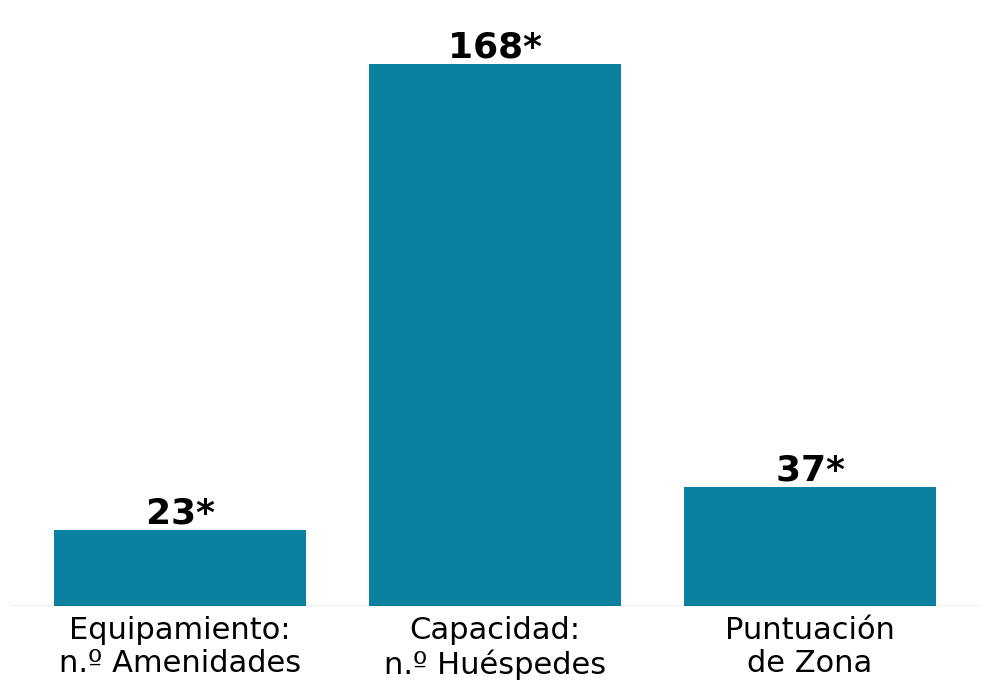

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.375
Method:                 Least Squares   F-statistic:                     629.7
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        18:07:24   Log-Likelihood:                -49352.
No. Observations:                6281   AIC:                         9.872e+04
Df Residuals:                    6274   BIC:                         9.877e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [ ]:
# en power bi, selecionar la columna "city" tambien, para visualizaciones interactivos (filtro por ciudad)
# en power bi, selecionar la columna "unique_id" tambien, para guardar todos los registros como en python

# dataset = pandas.DataFrame(unique_id, city, price, room_type, amenities_important_count, accommodates, review_scores_location)
# dataset = dataset.drop_duplicates()


# 1. Cargar paquetes de python en power bi
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import statsmodels.api as sm


# hacer este en powerbi si aun no está así
# dataset['review_scores_location'] = dataset['review_scores_location']/10


# 2. Selección de variables y limpieza de datos
# usamos el variable tipo de alojamiento para control ya que sabemos que afecta al precio, pero no lo mostramos en resultados
cols = ['price', 'room_type', 'amenities_important_count', 'accommodates', 'review_scores_location']
dataset_clean = dataset[cols].dropna()

# 3. Preparación de variables (Dummies para variables categóricas)
dataset_reg = pd.get_dummies(dataset_clean, columns=['room_type'], drop_first=True)

# Definimos X (predictores) y y (objetivo)
y = dataset_reg['price']
X = dataset_reg.drop('price', axis=1)
X = sm.add_constant(X) # Añadir intercepto

# 4. Ejecutar Regresión Lineal (OLS)
model = sm.OLS(y, X.astype(float)).fit()

# 5. Extraer coeficientes y p-valores
results = pd.DataFrame({
    'predictor': model.params.index,
    'coef': model.params.values,
    'p_value': model.pvalues.values
})

# Filtrar para el gráfico (excluir constantes y room_type)
target_predictors = ['amenities_important_count', 'accommodates', 'review_scores_location']
plot_dataset = results[results['predictor'].isin(target_predictors)].copy()

# Usamos \n para separar el texto en dos líneas
etiquetas_dos_lineas = {
    'amenities_important_count': 'Equipamiento:\nn.º Amenidades',
    'accommodates': 'Capacidad:\nn.º Huéspedes',
    'review_scores_location': 'Puntuación\nde Zona'
}

plot_dataset['predictor'] = plot_dataset['predictor'].map(etiquetas_dos_lineas)

# Color para diferenciar signo de Coeficientes
plot_dataset['color'] = plot_dataset['coef'].apply(lambda x: '#0b81a2' if x >= 0 else '#e25759')


# 6. Visualización
plt.figure(figsize=(10, 7))
bars = plt.bar(plot_dataset['predictor'], plot_dataset['coef'], color=plot_dataset['color'])

# Añadir etiquetas con formato negrita y '*' si es significativo
for bar, coef, p_val in zip(bars, plot_dataset['coef'], plot_dataset['p_value']):
    height = bar.get_height()
    label = f"$\\mathbf{{{coef:.0f}}}$"
    if p_val < 0.05:
        label += "$\\mathbf{*}$"
    else: label = f"{coef:.0f}"
    
    va = 'bottom' if height > 0 else 'top'
    plt.text(bar.get_x() + bar.get_width()/2, height, label, 
             ha='center', va=va, fontsize=26)

# Configurar leyendas separadas
legend_color = [Line2D([0], [0], color='#0b81a2', lw=4, label='Impacto Positivo'),
                Line2D([0], [0], color='#e25759', lw=4, label='Impacto Negativo')]

plt.legend('', frameon=False)

plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(fontsize = 22)
plt.yticks([])
plt.tick_params(axis="x", bottom=False)
plt.margins(y=0.1)
#plt.gca().spines[['top', 'left', 'right']].set_visible(False)
plt.box(False)
plt.tight_layout()
plt.show()


# Opcional: imprimir resumen
print(model.summary())

### Visualizacion de coeficientes de regresiones por ciudad (1): Todos coeficientes

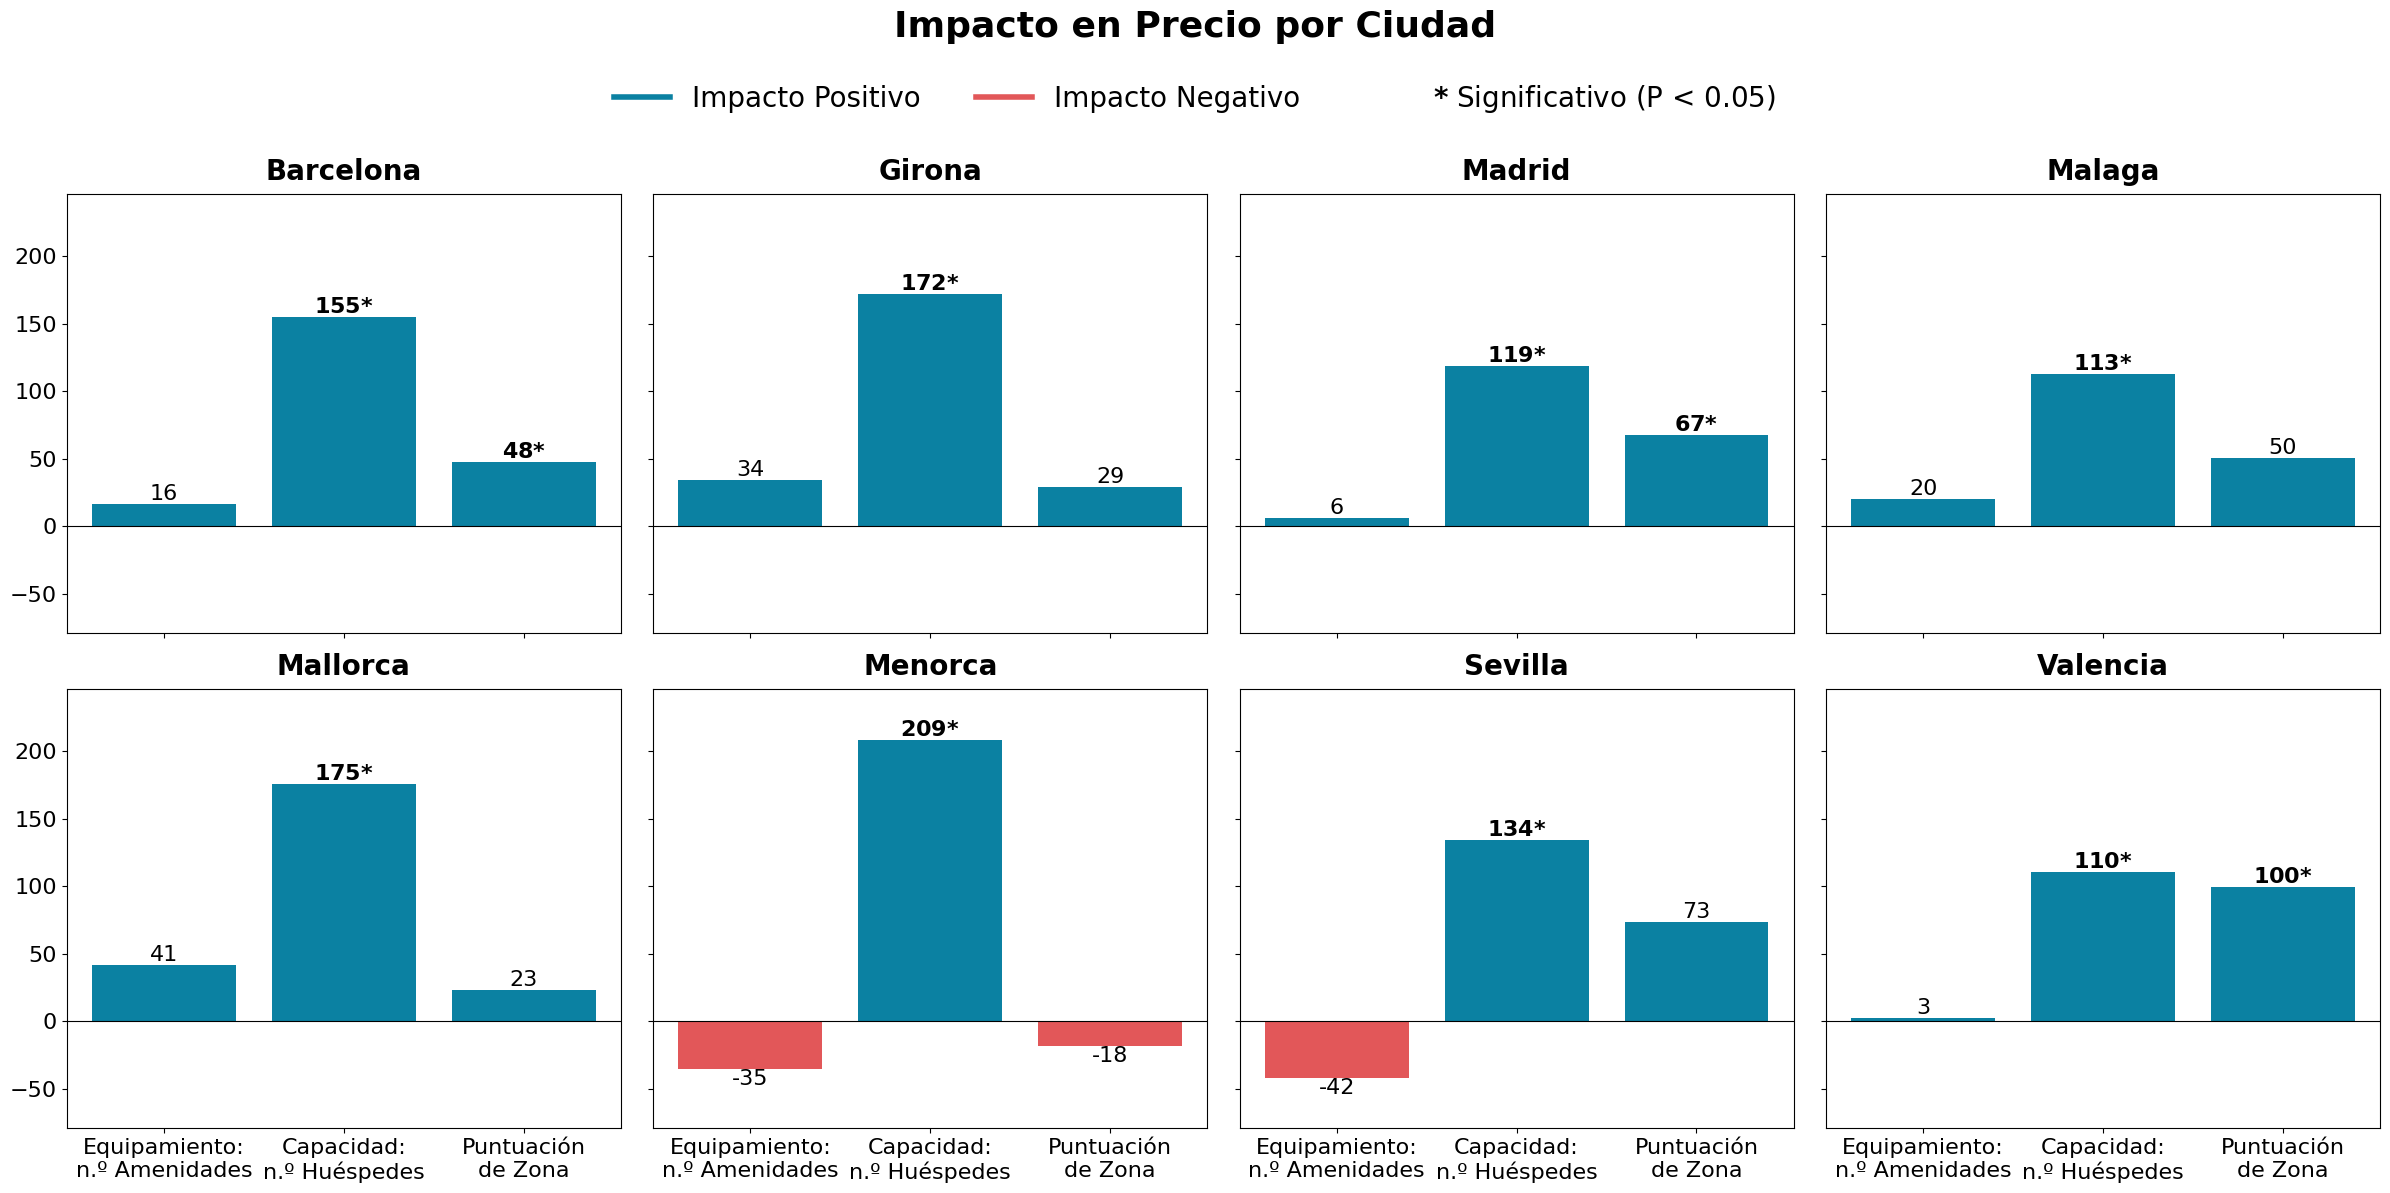

In [ ]:
# en power bi, selecionar la columna "unique_id" tambien, para guardar todos los registros como en python

# dataset = pandas.DataFrame(unique_id, city, price, room_type, amenities_important_count, accommodates, review_scores_location)
# dataset = dataset.drop_duplicates()


# 1. Cargar paquetes de python en power bi
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import statsmodels.api as sm


# hacer este en powerbi si aun no está así
# dataset['review_scores_location'] = dataset['review_scores_location']/10


# 2. PREPARACIÓN DE DATOS
# Seleccionamos las columnas necesarias para el análisis
cols = ['price', 'room_type', 'amenities_important_count', 'accommodates', 'review_scores_location', 'city']
# Eliminamos filas con valores nulos para asegurar que la regresión no falle
dataset_clean = dataset[cols].dropna()

# Definimos los predictores que queremos analizar en el eje X
target_predictors = ['amenities_important_count', 'accommodates', 'review_scores_location']

# Diccionario para convertir los nombres técnicos en etiquetas legibles de dos líneas
etiquetas_dos_lineas = {
    'amenities_important_count': 'Equipamiento:\nn.º Amenidades',
    'accommodates': 'Capacidad:\nn.º Huéspedes',
    'review_scores_location': 'Puntuación\nde Zona'
}

# 3. ANÁLISIS DE REGRESIÓN POR CIUDAD
ciudades = sorted(dataset_clean['city'].unique())
resultados_lista = []

for ciudad in ciudades:
    # Filtramos los datos para la ciudad actual
    df_ciudad = dataset_clean[dataset_clean['city'] == ciudad].copy()
    
    # Omitimos ciudades con muy pocos datos (mínimo 10 para validez estadística)
    if len(df_ciudad) < 10:
        continue
    
    # Transformamos la variable categórica 'room_type' en variables dummy (binarias)
    reg_ciudad = pd.get_dummies(df_ciudad, columns=['room_type'], drop_first=True)
    
    # Identificamos las columnas de control (tipos de habitación)
    room_cols = [c for c in reg_ciudad.columns if c.startswith('room_type_')]
    
    # Construimos la matriz de predictores completa
    X_cols = target_predictors + room_cols
    
    # Filtramos predictores que no tengan variación (constantes) en esta ciudad
    valid_X = [c for c in X_cols if reg_ciudad[c].nunique() > 1]
    
    # Definimos variable dependiente (precio) e independiente (X)
    y = reg_ciudad['price']
    X = sm.add_constant(reg_ciudad[valid_X])
    
    try:
        # Ejecutamos el modelo OLS (Mínimos Cuadrados Ordinarios)
        modelo = sm.OLS(y, X.astype(float)).fit()
        
        # Extraemos y guardamos los resultados de interés
        res = pd.DataFrame({
            'city': ciudad,
            'predictor': modelo.params.index,
            'coef': modelo.params.values,
            'p_value': modelo.pvalues.values
        })
        resultados_lista.append(res)
    except:
        continue

# Consolidamos todos los resultados en un único DataFrame
df_resultados = pd.concat(resultados_lista)

# 4. VISUALIZACIÓN: TODOS LOS PREDICTORES
ciudades_lista = sorted(df_resultados['city'].unique())
n_ciudades = len(ciudades_lista)
ncols = 4  # Configuramos 4 facetas por fila
nrows = (n_ciudades + ncols - 1) // ncols

# Creamos la figura con eje X compartido para que las etiquetas solo aparezcan abajo
fig, axes = plt.subplots(nrows, ncols, figsize=(24, 6 * nrows), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, ciudad in enumerate(ciudades_lista):
    ax = axes_flat[i]
    res_ciudad = df_resultados[df_resultados['city'] == ciudad]
    
    # Aseguramos que cada gráfico tenga exactamente los mismos predictores en el mismo orden
    filas_plot = []
    for pred in target_predictors:
        row = res_ciudad[res_ciudad['predictor'] == pred]
        if not row.empty:
            filas_plot.append(row.iloc[0])
        else:
            # Si el predictor no existe en el modelo de esa ciudad, ponemos valores en cero
            filas_plot.append({'predictor': pred, 'coef': 0, 'p_value': 1.0})
    
    df_plot = pd.DataFrame(filas_plot)
    df_plot['label'] = df_plot['predictor'].map(etiquetas_dos_lineas)
    
    # Asignamos colores: azul para impacto positivo, rojo para negativo
    df_plot['color'] = df_plot['coef'].apply(lambda x: '#0b81a2' if x >= 0 else '#e25759')
    
    # Dibujamos las barras
    barras = ax.bar(df_plot['label'], df_plot['coef'], color=df_plot['color'])
    ax.axhline(0, color='black', linewidth=0.8)  # Línea base en cero
    ax.set_title(f'{ciudad}', fontsize=20, fontweight='bold', pad=10)
    
    # Añadimos etiquetas numéricas sobre/bajo las barras
    for bar, raw_coef, p_val in zip(barras, df_plot['coef'], df_plot['p_value']):
        txt = f"$\\mathbf{{{raw_coef:.0f}}}$"
        if p_val < 0.05:
            txt += "$\\mathbf{*}$"  # Añadimos asterisco si es significativo
        else: txt = f"{raw_coef:.0f}"
        
        va = 'bottom' if raw_coef >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width()/2, raw_coef, txt, ha='center', va=va, fontsize=16)
    
    ax.tick_params(axis='y', labelsize=16)
    ax.tick_params(axis='x', labelsize=16)

    ax.set_ymargin(0.15) ## configular los limites de y axis
    #ax.set_ylim([-60, 230]) ## configular los limites de y axis

# Ocultamos los espacios de la cuadrícula que no tengan ciudad asignada
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

# Configuración de leyenda y títulos generales
elementos_leyenda = [
    Line2D([0], [0], color='#0b81a2', lw=4, label='Impacto Positivo'),
    Line2D([0], [0], color='#e25759', lw=4, label='Impacto Negativo'),
    Line2D([0], [0], marker='none', color='none', label='$\\mathbf{*}$ Significativo (P < 0.05)')
]
fig.legend(handles=elementos_leyenda, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=20, frameon=False)

plt.suptitle('Impacto en Precio por Ciudad', fontsize=26, y=1.02, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visualizacion de coeficientes de regresiones por ciudad (2): Solo coeficientes significativos

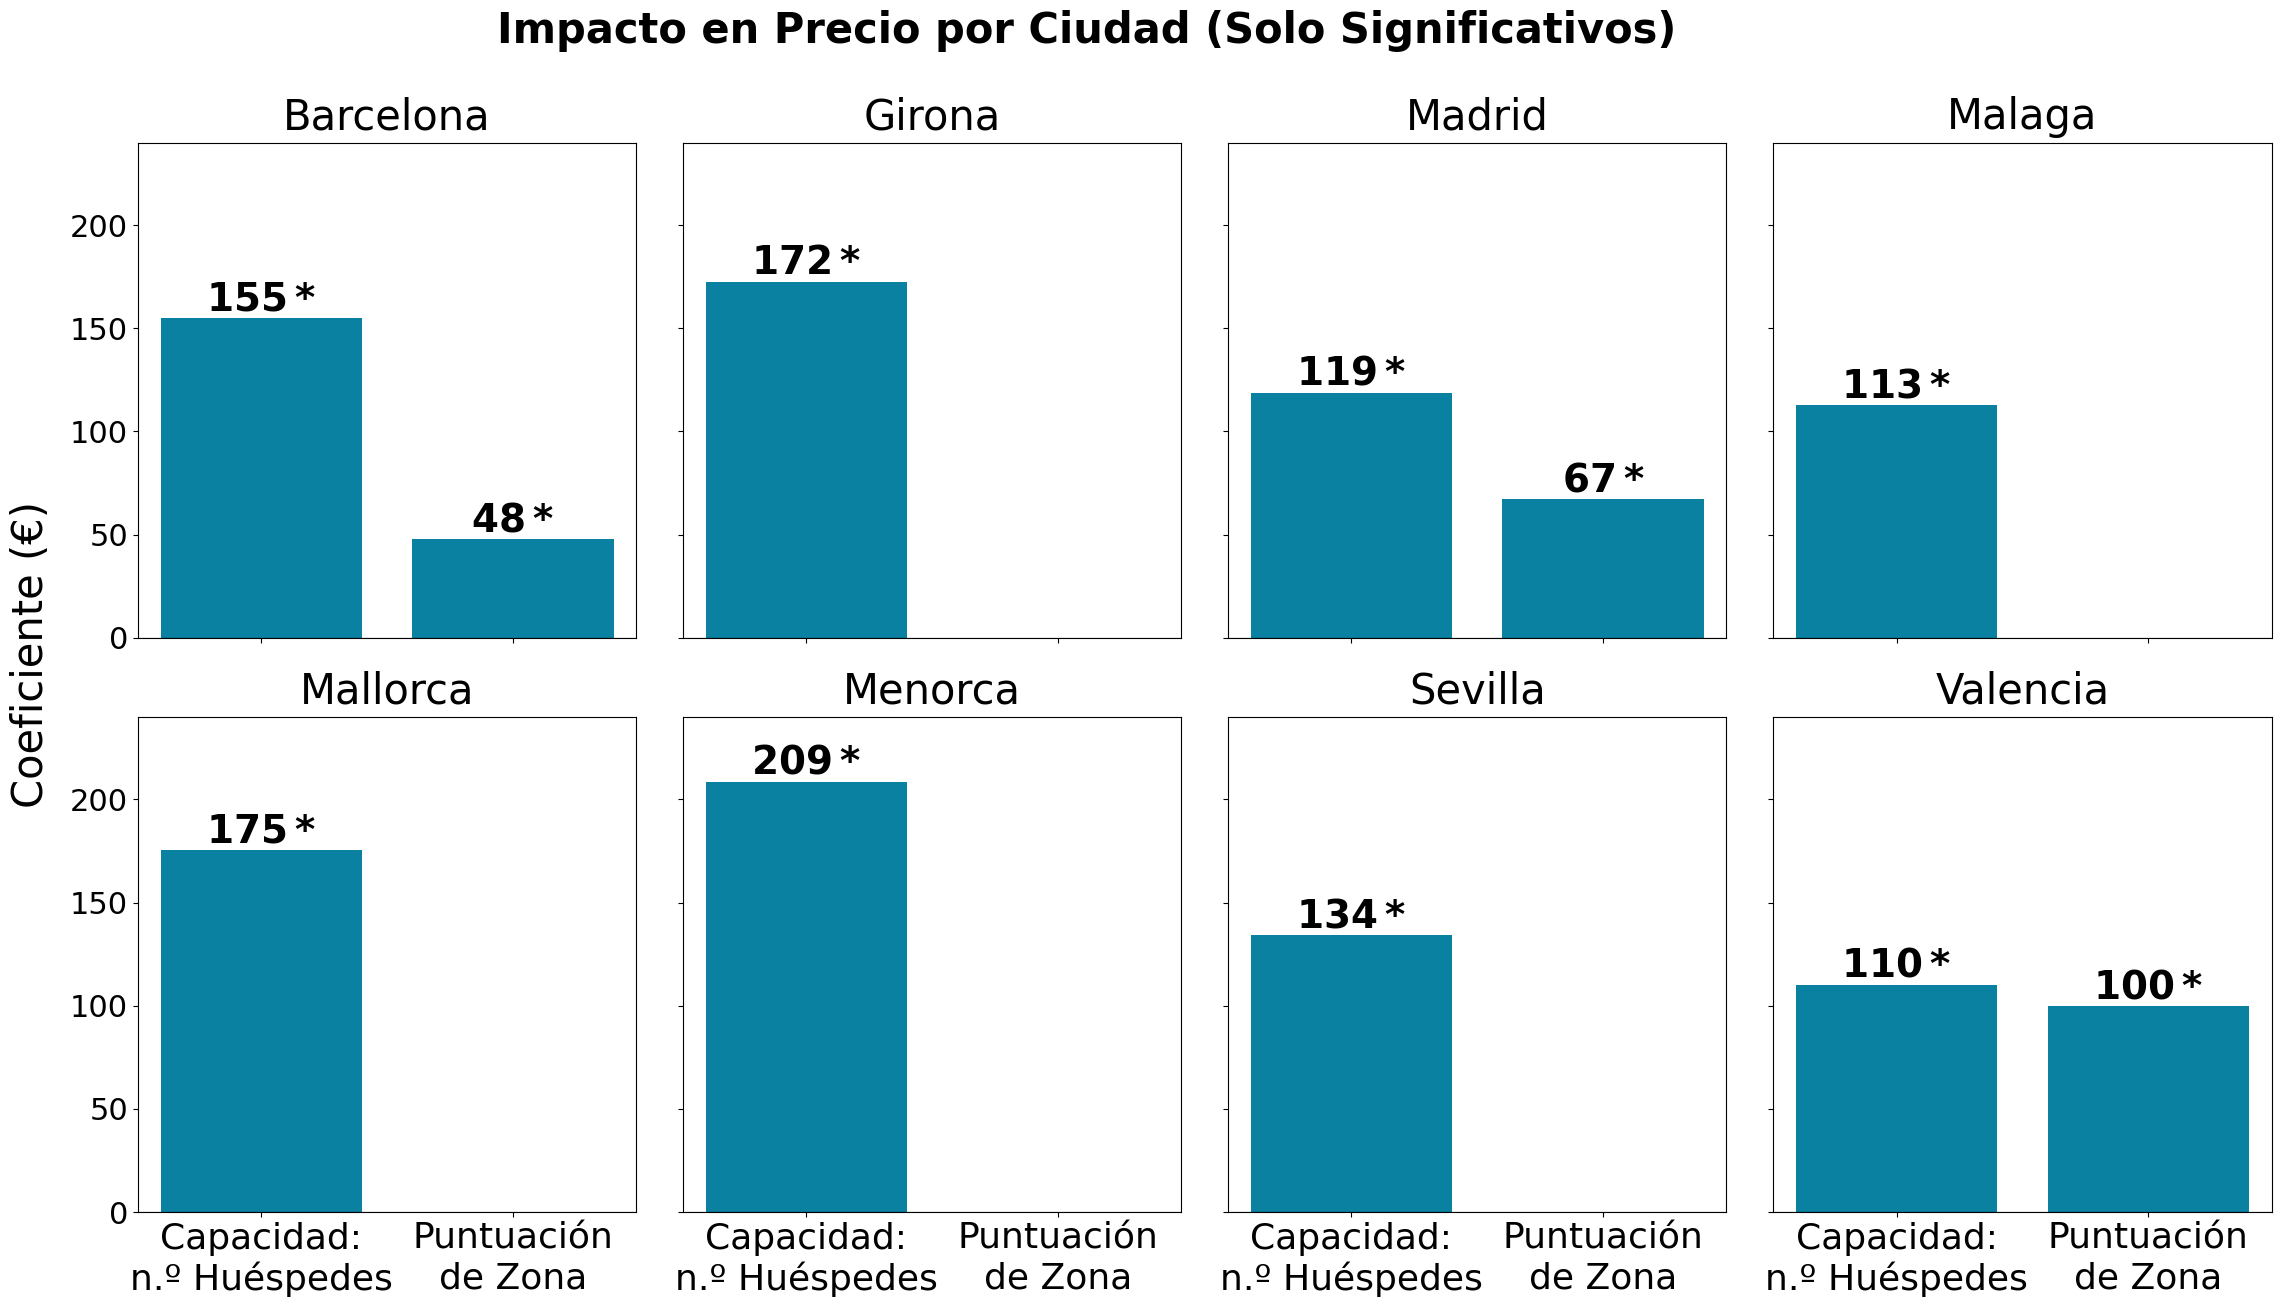

In [7]:
# en power bi, selecionar la columna "unique_id" tambien, para guardar todos los registros como en python

# dataset = pandas.DataFrame(unique_id, city, price, room_type, amenities_important_count, accommodates, review_scores_location)
# dataset = dataset.drop_duplicates()


# 1. Cargar paquetes de python en power bi
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import statsmodels.api as sm

# 1. PREPARACIÓN DE DATOS (REPETIDO PARA AUTONOMÍA DEL BLOQUE)
cols = ['price', 'room_type', 'amenities_important_count', 'accommodates', 'review_scores_location', 'city']
dataset_clean = dataset[cols].dropna()

target_predictors = ['amenities_important_count', 'accommodates', 'review_scores_location']
etiquetas_dos_lineas = {
    'amenities_important_count': 'Equipamiento:\nn.º Amenidades',
    'accommodates': 'Capacidad:\nn.º Huéspedes',
    'review_scores_location': 'Puntuación\nde Zona'
}

# 2. ANÁLISIS DE REGRESIÓN POR CIUDAD
ciudades = sorted(dataset_clean['city'].unique())
resultados_lista = []

for ciudad in ciudades:
    df_ciudad = dataset_clean[dataset_clean['city'] == ciudad].copy()
    if len(df_ciudad) < 10:
        continue
    
    reg_ciudad = pd.get_dummies(df_ciudad, columns=['room_type'], drop_first=True)
    room_cols = [c for c in reg_ciudad.columns if c.startswith('room_type_')]
    X_cols = target_predictors + room_cols
    valid_X = [c for c in X_cols if reg_ciudad[c].nunique() > 1]
    
    y = reg_ciudad['price']
    X = sm.add_constant(reg_ciudad[valid_X])
    
    try:
        modelo = sm.OLS(y, X.astype(float)).fit()
        res = pd.DataFrame({
            'city': ciudad,
            'predictor': modelo.params.index,
            'coef': modelo.params.values,
            'p_value': modelo.pvalues.values
        })
        resultados_lista.append(res)
    except:
        continue

df_resultados = pd.concat(resultados_lista)

# 3. VISUALIZACIÓN: SOLO PREDICTORES SIGNIFICATIVOS
ciudades_lista = sorted(df_resultados['city'].unique())
n_ciudades = len(ciudades_lista)
ncols = 4
nrows = (n_ciudades + ncols - 1) // ncols

# Usamos sharex=True para que las etiquetas del eje X solo aparezcan en la base del gráfico total
fig, axes = plt.subplots(nrows, ncols, figsize=(24, 7 * nrows), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, ciudad in enumerate(ciudades_lista):
    ax = axes_flat[i]
    res_ciudad = df_resultados[df_resultados['city'] == ciudad]
    
    filas_plot = []
    for pred in target_predictors:
        row = res_ciudad[res_ciudad['predictor'] == pred]
        if not row.empty:
            filas_plot.append(row.iloc[0])
        else:
            filas_plot.append({'predictor': pred, 'coef': 0, 'p_value': 1.0})
    
    df_plot = pd.DataFrame(filas_plot)

    # excluir 'amenities_important_count' porque no es significativo en ninguna ciudad
    df_plot = df_plot.drop(df_plot[df_plot['predictor'] == 'amenities_important_count'].index)

    df_plot['label'] = df_plot['predictor'].map(etiquetas_dos_lineas)
    
    # LÓGICA CLAVE: Si el valor p >= 0.05, la altura de la barra es 0
    df_plot['altura_visual'] = df_plot.apply(lambda r: r['coef'] if r['p_value'] < 0.05 else 0, axis=1)
    df_plot['color'] = df_plot['altura_visual'].apply(lambda x: '#0b81a2' if x >= 0 else '#e25759')
    
    # Dibujamos las barras (las no significativas tendrán altura cero)
    barras = ax.bar(df_plot['label'], df_plot['altura_visual'], color=df_plot['color'])
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{ciudad}', fontsize=30, pad=10)
    
    # Solo añadimos texto si la barra es significativa
    for bar, raw_coef, p_val, height in zip(barras, df_plot['coef'], df_plot['p_value'], df_plot['altura_visual']):
        if p_val < 0.05:
            txt = f"$\\mathbf{{{raw_coef:.0f}*}}$"
            va = 'bottom' if height >= 0 else 'top'
            ax.text(bar.get_x() + bar.get_width()/2, height, txt, ha='center', va=va, fontsize=28)
    
    ax.tick_params(axis='y', labelsize=22)
    ax.tick_params(axis='x', labelsize=26)


    ax.set_ymargin(0.15) ## configular los limites de y axis
    #ax.set_ylim([0, 230]) ## configular los limites de y axis


# Limpieza de subplots vacíos
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis('off')

# Leyenda y Titulado
elementos_leyenda = [
    Line2D([0], [0], color='#0b81a2', lw=4, label='Impacto Positivo'),
    Line2D([0], [0], color='#e25759', lw=4, label='Impacto Negativo'),
    Line2D([0], [0], marker='none', color='none', label='$\\mathbf{*}$ Significativo (P < 0.05)')
]
# fig.legend(handles=elementos_leyenda, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=20, frameon=False)
# aquí no necesitamos legends

plt.suptitle('Impacto en Precio por Ciudad (Solo Significativos)', fontsize=30, y=0.96, fontweight='bold')
fig.text(0.06, 0.5, 'Coeficiente (€)', fontsize=30, ha='center', va='center', rotation='vertical')
plt.tight_layout(rect=[0.07, 0.03, 1, 0.95])
plt.show()